<a href="https://colab.research.google.com/github/Bunty-Bot/deep_learning_MBFProject/blob/main/DL_GO_Data_MBFProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import re
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import multilabel_confusion_matrix
import wandb
import pandas as pd
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
np.random.seed(42)

In [ ]:
!git clone https://git.wur.nl/bioinformatics/grs34806-deep-learning-project-data.git
os.chdir("grs34806-deep-learning-project-data")

Cloning into 'grs34806-deep-learning-project-data'...
remote: Enumerating objects: 21, done.
remote: Total 21 (delta 0), reused 0 (delta 0), pack-reused 21 (from 1)
Receiving objects: 100% (21/21), 8.74 MiB | 5.20 MiB/s, done.


In [ ]:
seqfile = "expr5Tseq_filtGO_100-1000.lis"

ids, seqs = [], []
with open(seqfile) as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        if "\t" in line:
            pid, s = line.split("\t", 1)
        else:
            m = re.match(r"^([^A-Z]+)([A-Z].*)$", line)
            if not m:
                continue
            pid, s = m.group(1), m.group(2)
        ids.append(pid.strip())
        seqs.append(s.strip())

go_terms = [
    ("GO_3A0005739.annotprot", "mitochondrion"),
    ("GO_3A0007165.annotprot", "signal_transduction"),
    ("GO_3A0005576.annotprot", "extracellular"),
    ("GO_3A0055085.annotprot", "transmembrane"),
    ("GO_3A0043066.annotprot", "neg_apoptosis"),
]

id2idx = {pid: i for i, pid in enumerate(ids)}
labels = np.zeros((len(ids), len(go_terms)), dtype=np.float32)

for col, (fname, _) in enumerate(go_terms):
    with open(fname) as f:
        pos_ids = [l.strip() for l in f if l.strip()]
    for pid in pos_ids:
        if pid in id2idx:
            labels[id2idx[pid], col] = 1.0

labels = torch.tensor(labels)

In [ ]:
mapaa2num = {aa: i for i, aa in enumerate(list("ACDEFGHIKLMNPQRSTVWY"))}

def tokenize_seq(seq, map2num, non_aa_num=20):
    return [map2num.get(ch, non_aa_num) for ch in seq]

def truncate_pad(line, num_steps, padding_token):
    if len(line) > num_steps:
        return line[:num_steps]
    return line + [padding_token] * (num_steps - len(line))

def build_seq_array(seqs, num_steps, non_aa_num=20):
    return torch.tensor([truncate_pad(s, num_steps, non_aa_num) for s in seqs], dtype=torch.long)

num_steps = 1000
X = build_seq_array([tokenize_seq(s, mapaa2num) for s in seqs], num_steps)

In [ ]:
class SequenceDatasetOneHot(Dataset):
    def __init__(self, sequences, labels, num_steps, map2num=mapaa2num, non_aa_num=20):
        self.num_steps = num_steps
        self.non_aa_num = non_aa_num
        self.map2num = map2num
        self.sequences = [tokenize_seq(s, self.map2num) for s in sequences]
        self.padded_sequences = torch.tensor([truncate_pad(s, num_steps, non_aa_num) for s in self.sequences], dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.float32) # Dummy labels, not used for prediction

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.padded_sequences[idx], self.labels[idx]

In [ ]:
perm = torch.randperm(len(X))
n_train = int(0.7 * len(X))
n_val = int(0.15 * len(X))

train_idx = perm[:n_train]
val_idx = perm[n_train:n_train + n_val]
test_idx = perm[n_train + n_val:]

X_train, y_train = X[train_idx], labels[train_idx]
X_val, y_val = X[val_idx], labels[val_idx]
X_test, y_test = X[test_idx], labels[test_idx]

In [ ]:
batch_size = 32
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

In [ ]:
@torch.no_grad()
def evaluate_loss(model, loader, criterion):
    model.eval()
    losses = []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        loss = criterion(model(xb), yb)
        losses.append(loss.item())
    return float(np.mean(losses))

@torch.no_grad()
def predict_probs(model, loader):
    model.eval()
    probs_list, y_list = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        logits = model(xb)
        probs = torch.sigmoid(logits).cpu().numpy()
        probs_list.append(probs)
        y_list.append(yb.numpy())
    return np.vstack(probs_list), np.vstack(y_list)

def multilabel_metrics(y_true, y_prob):
    out = {}
    out["mAUPRC"] = float(np.mean([
        average_precision_score(y_true[:, i], y_prob[:, i])
        for i in range(y_true.shape[1])
        if y_true[:, i].sum() > 0
    ]))
    out["mAUROC"] = float(np.mean([
        roc_auc_score(y_true[:, i], y_prob[:, i])
        for i in range(y_true.shape[1])
        if len(np.unique(y_true[:, i])) > 1
    ]))
    out["micro_F1"] = float(f1_score(y_true.ravel(), (y_prob.ravel() >= 0.5).astype(int), zero_division=0))
    return out

@torch.no_grad()
def eval_auprc(model, loader):
    probs, true_labels = predict_probs(model, loader)
    metrics = multilabel_metrics(true_labels, probs)
    return metrics['mAUPRC']

def plot_multilabel_confusion_matrices(y_true, y_prob, go_terms, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    cms = multilabel_confusion_matrix(y_true, y_pred)

    n = len(go_terms)
    ncols = 2
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, (_, name) in enumerate(go_terms):
        cm = cms[i]
        ax = axes[i]
        im = ax.imshow(cm, cmap="Blues")
        ax.set_title(name)
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(["Pred 0", "Pred 1"])
        ax.set_yticklabels(["True 0", "True 1"])

        for r in range(2):
            for c in range(2):
                ax.text(c, r, int(cm[r, c]), ha="center", va="center", color="black")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
class ProteinCNN(nn.Module):
    def __init__(self, vocab_size=21, emb_dim=64, conv_channels=128, dropout=0.1, n_labels=5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size + 1, emb_dim, padding_idx=vocab_size)
        self.net = nn.Sequential(
            nn.Conv1d(emb_dim, conv_channels, kernel_size=8, padding=4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.MaxPool1d(2),
            nn.Conv1d(conv_channels, conv_channels, kernel_size=8, padding=4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.AdaptiveMaxPool1d(1),
            nn.Flatten(),
            nn.Linear(conv_channels, n_labels),
        )

    def forward(self, x):
        x = self.embedding(x).transpose(1, 2)
        return self.net(x)

In [ ]:
!pip install wandb -q

In [ ]:
wandb.init(
    project="protein-go-prediction",
    name="cnn-run-width",
    config={
        "model": "CNN",
        "dropout": 0.1,
        "lr": 1e-3,
        "batch_size": 32,
        "num_steps": 1000,
    }
)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: shreyas-ba14 (shreyas-ba14-wageningen-academic-publishers) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
pos = y_train.sum(0)
neg = y_train.size(0) - pos
pos_weight = (neg / pos.clamp(min=1)).to(device)

torch.manual_seed(0)
net = ProteinCNN(dropout=0.3, n_labels=labels.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(net.parameters(), lr=3e-4, weight_decay=1e-2)

best_val = -1
best_state = None
patience = 5
wait = 0

for epoch in range(1, 26):
    net.train()
    total_train_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = net(xb)
        loss = criterion(logits, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item() * xb.size(0)

    train_loss = total_train_loss / len(train_loader.dataset)
    val_loss = evaluate_loss(net, val_loader, criterion)

    val_probs, val_true = predict_probs(net, val_loader)
    val_metrics = multilabel_metrics(val_true, val_probs)

    wandb.log({
        "epoch": epoch,
        "train/loss": train_loss,
        "val/loss": val_loss,
        "val/mAUPRC": val_metrics["mAUPRC"],
        "val/mAUROC": val_metrics["mAUROC"],
        "val/micro_F1": val_metrics["micro_F1"],
    })

    for i, (_, name) in enumerate(go_terms):
        wandb.log({
            f"val/AUROC_{name}": roc_auc_score(val_true[:, i], val_probs[:, i]),
            f"val/AUPRC_{name}": average_precision_score(val_true[:, i], val_probs[:, i]),
        })

    print(f"epoch {epoch:02d} train loss {train_loss:.4f} val loss {val_loss:.4f} val mAUPRC {val_metrics['mAUPRC']:.4f}")

    if val_metrics["mAUPRC"] > best_val:
        best_val = val_metrics["mAUPRC"]
        best_state = copy.deepcopy(net.state_dict())
        wait = 0
    else:
        wait += 1

    if wait >= patience:
        break

net.load_state_dict(best_state)

epoch 01 train loss 1.3522 val loss 1.4016 val mAUPRC 0.1221
epoch 02 train loss 1.2895 val loss 1.3583 val mAUPRC 0.1634
epoch 03 train loss 1.1992 val loss 1.3157 val mAUPRC 0.1773
epoch 04 train loss 1.1395 val loss 1.2873 val mAUPRC 0.1938
epoch 05 train loss 1.0682 val loss 1.2413 val mAUPRC 0.2061
epoch 06 train loss 1.0330 val loss 1.2398 val mAUPRC 0.2246
epoch 07 train loss 0.9603 val loss 1.2427 val mAUPRC 0.2220
epoch 08 train loss 0.9377 val loss 1.2009 val mAUPRC 0.2251
epoch 09 train loss 0.8574 val loss 1.2372 val mAUPRC 0.2350
epoch 10 train loss 0.8166 val loss 1.1833 val mAUPRC 0.2411
epoch 11 train loss 0.7434 val loss 1.2231 val mAUPRC 0.2500
epoch 12 train loss 0.7132 val loss 1.1881 val mAUPRC 0.2487
epoch 13 train loss 0.6644 val loss 1.1884 val mAUPRC 0.2517
epoch 14 train loss 0.6126 val loss 1.2904 val mAUPRC 0.2708
epoch 15 train loss 0.5675 val loss 1.2697 val mAUPRC 0.2855
epoch 16 train loss 0.4949 val loss 1.3153 val mAUPRC 0.2740
epoch 17 train loss 0.47

<All keys matched successfully>

### Accuracy per GO Term on Training Set

/tmp/ipykernel_1466/4231576178.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="GO Term", y="Accuracy", data=accuracy_df_train, palette="viridis")


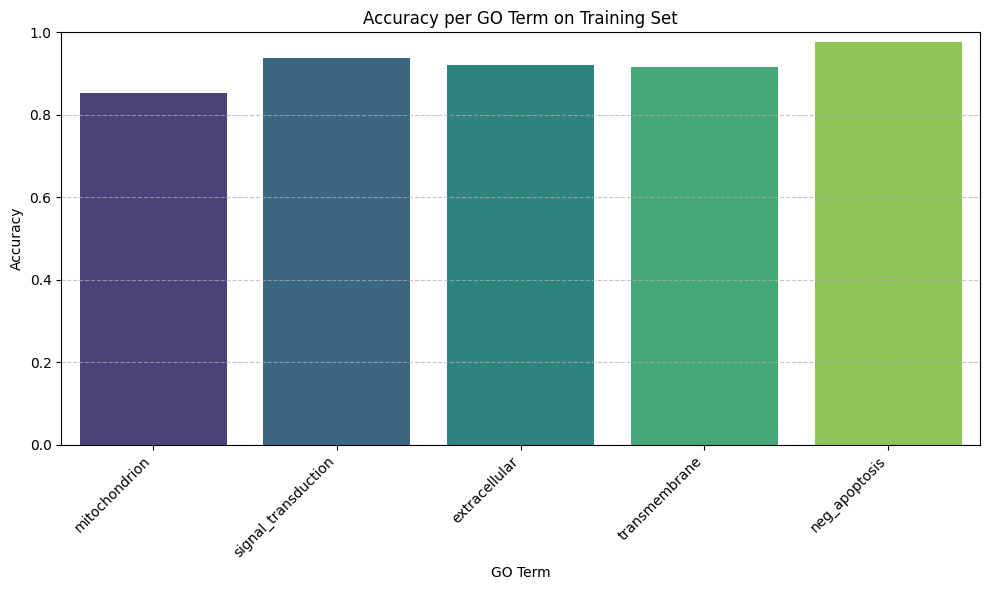

In [ ]:
train_probs, train_true = predict_probs(net, train_loader)

accuracy_scores_per_label_train = []
for i, (_, name) in enumerate(go_terms):
    acc_train = accuracy_score(train_true[:, i], (train_probs[:, i] >= 0.5).astype(int))
    accuracy_scores_per_label_train.append({"GO Term": name, "Accuracy": acc_train})

accuracy_df_train = pd.DataFrame(accuracy_scores_per_label_train)

plt.figure(figsize=(10, 6))
sns.barplot(x="GO Term", y="Accuracy", data=accuracy_df_train, palette="viridis")
plt.title("Accuracy per GO Term on Training Set")
plt.xlabel("GO Term")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Classification Report for Training Set

In [ ]:
# Generate predictions for the training set
train_probs, train_true = predict_probs(net, train_loader)
train_pred = (train_probs >= 0.5).astype(int)

# Prepare target names for the report
target_names = [name for _, name in go_terms]

# Print the classification report for the training set
print("Training Set Classification Report:")
print(classification_report(train_true, train_pred, target_names=target_names, zero_division=0))

Training Set Classification Report:
                     precision    recall  f1-score   support

      mitochondrion       0.32      1.00      0.48       325
signal_transduction       0.50      0.98      0.67       302
      extracellular       0.35      1.00      0.52       204
      transmembrane       0.28      1.00      0.43       153
      neg_apoptosis       0.52      1.00      0.68       122

          micro avg       0.37      0.99      0.54      1106
          macro avg       0.39      1.00      0.56      1106
       weighted avg       0.39      0.99      0.55      1106
        samples avg       0.18      0.21      0.19      1106



### Classification Report for Validation Set

In [ ]:
# Generate predictions for the validation set
val_probs, val_true = predict_probs(net, val_loader)
val_pred = (val_probs >= 0.5).astype(int)

# Prepare target names for the report
target_names = [name for _, name in go_terms]

# Print the classification report for the validation set
print("Validation Set Classification Report:")
print(classification_report(val_true, val_pred, target_names=target_names, zero_division=0))

Validation Set Classification Report:
                     precision    recall  f1-score   support

      mitochondrion       0.19      0.53      0.28        79
signal_transduction       0.11      0.18      0.14        65
      extracellular       0.32      0.72      0.45        60
      transmembrane       0.22      0.74      0.34        38
      neg_apoptosis       0.11      0.14      0.12        29

          micro avg       0.21      0.48      0.29       271
          macro avg       0.19      0.46      0.27       271
       weighted avg       0.20      0.48      0.27       271
        samples avg       0.10      0.12      0.11       271



### Evaluate Model on Test Set

In [ ]:
test_probs, test_true = predict_probs(net, test_loader)
test_metrics = multilabel_metrics(test_true, test_probs)

print(f"Test mAUPRC: {test_metrics['mAUPRC']:.4f}")
print(f"Test mAUROC: {test_metrics['mAUROC']:.4f}")
print(f"Test micro F1: {test_metrics['micro_F1']:.4f}")

wandb.log({
    "test/mAUPRC": test_metrics["mAUPRC"],
    "test/mAUROC": test_metrics["mAUROC"],
    "test/micro_F1": test_metrics["micro_F1"],
})

for i, (_, name) in enumerate(go_terms):
    wandb.log({
        f"test/AUROC_{name}": roc_auc_score(test_true[:, i], test_probs[:, i]),
        f"test/AUPRC_{name}": average_precision_score(test_true[:, i], test_probs[:, i]),
    })

Test mAUPRC: 0.2505
Test mAUROC: 0.7410
Test micro F1: 0.2659


### Accuracy per GO Term

/tmp/ipykernel_1466/1299341180.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="GO Term", y="Accuracy", data=accuracy_df, palette="viridis")


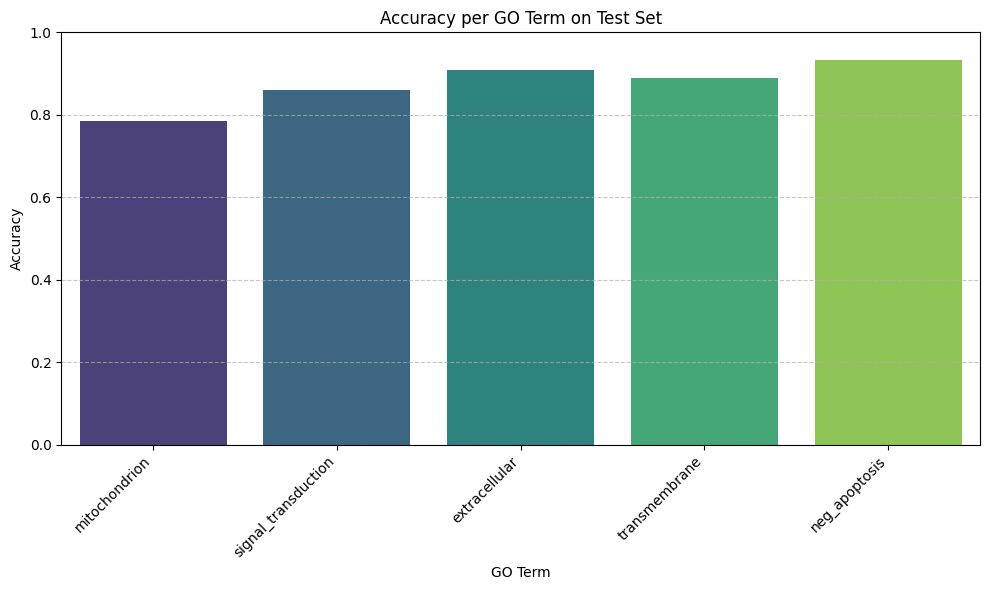

In [ ]:
accuracy_scores_per_label = []
for i, (_, name) in enumerate(go_terms):
    acc = accuracy_score(test_true[:, i], (test_probs[:, i] >= 0.5).astype(int))
    accuracy_scores_per_label.append({"GO Term": name, "Accuracy": acc})

accuracy_df = pd.DataFrame(accuracy_scores_per_label)

plt.figure(figsize=(10, 6))
sns.barplot(x="GO Term", y="Accuracy", data=accuracy_df, palette="viridis")
plt.title("Accuracy per GO Term on Test Set")
plt.xlabel("GO Term")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Confusion Matrices for Each GO Term

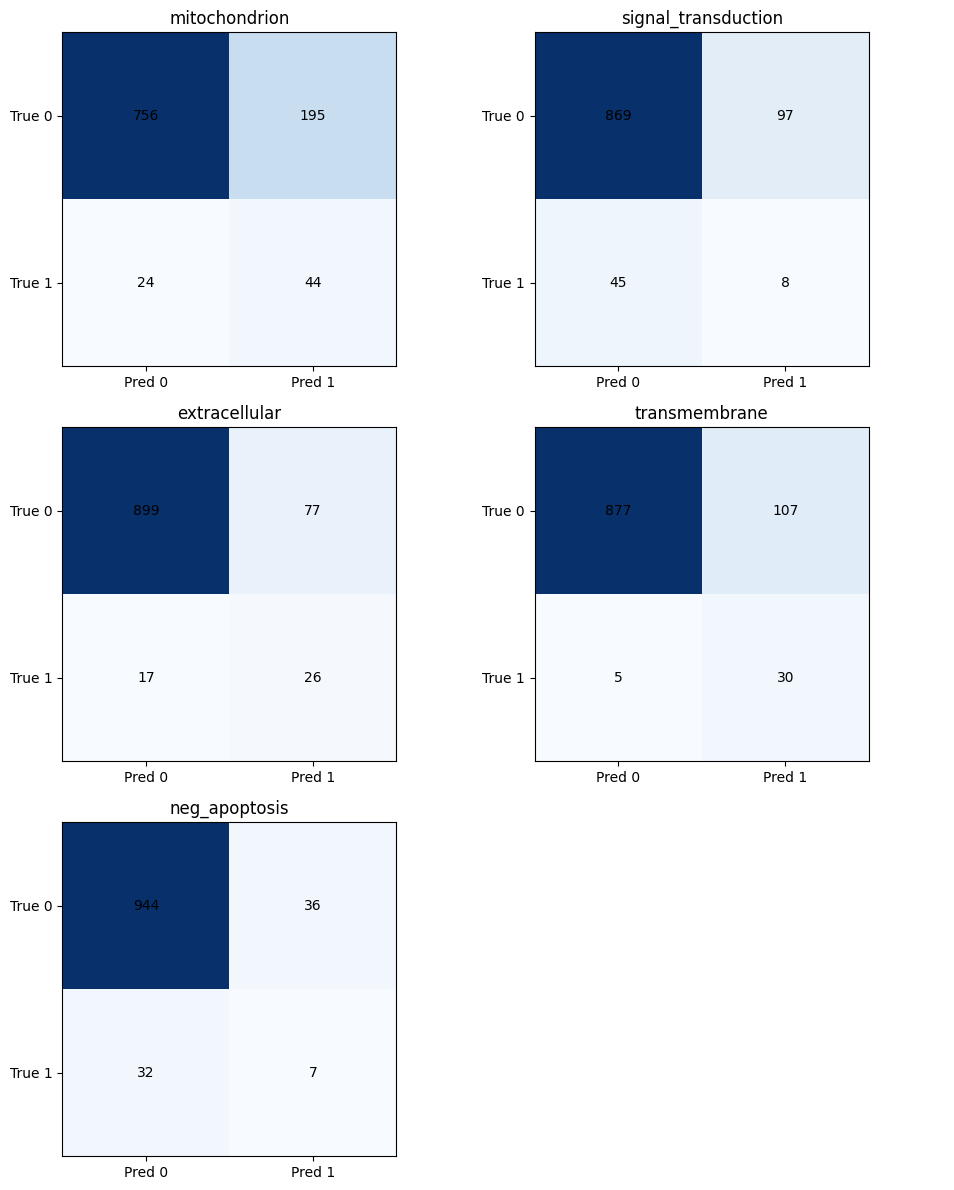

In [ ]:
plot_multilabel_confusion_matrices(test_true, test_probs, go_terms)

### Classification Report for Test Set

In [ ]:
# Generate predictions for the test set
test_probs, test_true = predict_probs(net, test_loader)
test_pred = (test_probs >= 0.5).astype(int)

# Prepare target names for the report
target_names = [name for _, name in go_terms]

# Print the classification report for the test set
print("Test Set Classification Report:")
print(classification_report(test_true, test_pred, target_names=target_names, zero_division=0))

Test Set Classification Report:
                     precision    recall  f1-score   support

      mitochondrion       0.18      0.65      0.29        68
signal_transduction       0.08      0.15      0.10        53
      extracellular       0.25      0.60      0.36        43
      transmembrane       0.22      0.86      0.35        35
      neg_apoptosis       0.16      0.18      0.17        39

          micro avg       0.18      0.48      0.27       238
          macro avg       0.18      0.49      0.25       238
       weighted avg       0.17      0.48      0.25       238
        samples avg       0.09      0.10      0.10       238



In [ ]:
wandb.finish()

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
test/AUPRC_extracellular,▁
test/AUPRC_mitochondrion,▁
test/AUPRC_neg_apoptosis,▁
test/AUPRC_signal_transduction,▁
test/AUPRC_transmembrane,▁
test/AUROC_extracellular,▁
test/AUROC_mitochondrion,▁
test/AUROC_neg_apoptosis,▁
test/AUROC_signal_transduction,▁
+19,...


In [ ]:
# Read the final unlabeled test set — FASTA format
# (protein IDs in >header lines, sequences on the next line(s))

def read_fasta(fastafile):
    """Read a FASTA file and return a dict {protein_id: sequence}."""
    seqs = {}
    current_id = None
    current_seq = []
    with open(fastafile) as f:
        for line in f:
            line = line.strip()
            if line.startswith('>'):
                if current_id is not None:
                    seqs[current_id] = ''.join(current_seq)
                current_id = line[1:].split()[0]  # take first word after >
                current_seq = []
            else:
                current_seq.append(line)
    if current_id is not None:
        seqs[current_id] = ''.join(current_seq)
    print(f"Loaded {len(seqs)} sequences from {fastafile}")
    return seqs

# Load it
test_fasta = read_fasta("test_set_filt.f")

Loaded 14765 sequences from test_set_filt.f


In [ ]:
# Create a Dataset and DataLoader for the unlabeled test sequences
fasta_ids = list(test_fasta.keys())
fasta_seqs = list(test_fasta.values())

# Dummy labels, as we don't have them for the unlabeled test set
# The predict_probs function expects a DataLoader of (X, y)
# So we create a TensorDataset with dummy labels, which will be ignored during prediction
dummy_labels_fasta = torch.zeros((len(fasta_seqs), len(go_terms)), dtype=torch.float32)

# Use the SequenceDatasetOneHot defined earlier
fasta_dataset = SequenceDatasetOneHot(fasta_seqs, dummy_labels_fasta, num_steps)
fasta_loader = DataLoader(fasta_dataset, batch_size=32, shuffle=False)

# Predict probabilities using the trained 'net' model
print("Making predictions on the unlabeled test set...")
unlabeled_test_probs, _ = predict_probs(net, fasta_loader)

# Apply a threshold (e.g., 0.5) to get binary predictions
unlabeled_test_predictions = (unlabeled_test_probs >= 0.5).astype(int)

# Print the number of positive predictions for each GO term
print("\nPredicted positives per GO term (using 0.5 threshold):")
for i, (_, name) in enumerate(go_terms):
    n_pos = np.sum(unlabeled_test_predictions[:, i])
    print(f"{name}: {n_pos} proteins predicted positive out of {len(fasta_ids)}")

/tmp/ipykernel_1466/2353983955.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.labels = torch.tensor(labels, dtype=torch.float32) # Dummy labels, not used for prediction


Making predictions on the unlabeled test set...

Predicted positives per GO term (using 0.5 threshold):
mitochondrion: 3151 proteins predicted positive out of 14765
signal_transduction: 1323 proteins predicted positive out of 14765
extracellular: 2354 proteins predicted positive out of 14765
transmembrane: 1265 proteins predicted positive out of 14765
neg_apoptosis: 457 proteins predicted positive out of 14765


/tmp/ipykernel_1466/1648337790.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='GO Term', y='Predicted Positives', data=plot_df, palette='viridis')


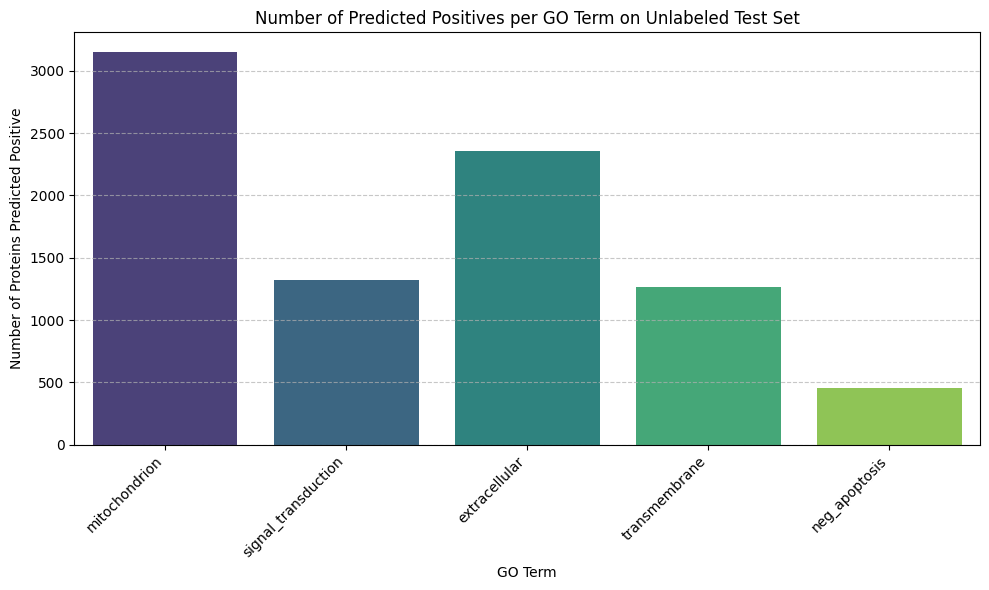

In [ ]:
# Prepare data for plotting
plot_data = []
for i, (_, name) in enumerate(go_terms):
    n_pos = np.sum(unlabeled_test_predictions[:, i])
    plot_data.append({'GO Term': name, 'Predicted Positives': n_pos})

plot_df = pd.DataFrame(plot_data)

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='GO Term', y='Predicted Positives', data=plot_df, palette='viridis')
plt.title('Number of Predicted Positives per GO Term on Unlabeled Test Set')
plt.xlabel('GO Term')
plt.ylabel('Number of Proteins Predicted Positive')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
!pip install transformers -q
from transformers import AutoTokenizer, AutoModel

# preprocessing helpers from the project handout
context_size = 1000

def pad_or_trim(seq, size):
    if len(seq) > size:
        return seq[:size]
    else:
        return seq + '_' * (size - len(seq))

def add_spaces_between_characters(seq):
    return ''.join(f'{s} ' for s in seq)[:-1]

def prepare_seq(seq):
    seq = pad_or_trim(seq, context_size)
    seq = add_spaces_between_characters(seq)
    seq = re.sub(r"[UZOB]", "X", seq)
    return seq

In [ ]:

esm_tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t6_8M_UR50D")
base_model    = AutoModel.from_pretrained("facebook/esm2_t6_8M_UR50D")

for parameter in base_model.parameters():
    parameter.requires_grad = False

base_model = base_model.to(device)
base_model.eval()
print("embedding dim:", base_model.config.hidden_size)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/31.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


embedding dim: 320


In [ ]:
# run every sequence through ESM-2, mean-pool to get one vector per protein
emb_batch  = 16
embeddings = []

with torch.no_grad():
    for i in range(0, len(seqs), emb_batch):
        batch  = [prepare_seq(s) for s in seqs[i:i+emb_batch]]
        tokens = esm_tokenizer(batch, return_tensors="pt", padding=True, truncation=True)
        tokens = {k: v.to(device) for k, v in tokens.items()}
        out    = base_model(**tokens).last_hidden_state
        embeddings.append(out.mean(dim=1).cpu())
        if i % 800 == 0:
            print(i)

embeddings = torch.cat(embeddings, dim=0)
embeddings.shape

0
800
1600
2400
3200
4000
4800
5600
6400


torch.Size([6784, 320])

In [ ]:

emb_dim = base_model.config.hidden_size

E_train = embeddings[train_idx]
E_val   = embeddings[val_idx]
E_test  = embeddings[test_idx]

esm_train_iter = DataLoader(TensorDataset(E_train, y_train), batch_size=64, shuffle=True)
esm_val_iter   = DataLoader(TensorDataset(E_val,   y_val),   batch_size=64)
esm_test_iter  = DataLoader(TensorDataset(E_test,  y_test),  batch_size=64)

class ESMHead(nn.Module):
    def __init__(self, emb_dim, n_labels=5, dropout=0.1):
        super().__init__()
        self.fc1     = nn.Linear(emb_dim, 128)
        self.dropout = nn.Dropout(dropout)
        self.fc2     = nn.Linear(128, n_labels)

    def forward(self, x):
        return self.fc2(self.dropout(F.relu(self.fc1(x))))

head_8m    = ESMHead(emb_dim=emb_dim, n_labels=labels.shape[1], dropout=0.1).to(device)
head_loss  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
head_opt   = torch.optim.AdamW(head_8m.parameters(), lr=1e-3, weight_decay=1e-2)

best_val, best_state, no_improve, patience = -1, None, 0, 15

for epoch in range(1, 101):
    head_8m.train()
    total = 0.0
    for xb, yb in esm_train_iter:
        xb, yb = xb.to(device), yb.to(device)
        loss = head_loss(head_8m(xb), yb)
        head_opt.zero_grad()
        loss.backward()
        head_opt.step()
        total += loss.item() * xb.size(0)
    val_auprc = eval_auprc(head_8m, esm_val_iter)
    if val_auprc > best_val:
        best_val, best_state, no_improve = val_auprc, copy.deepcopy(head_8m.state_dict()), 0
    else:
        no_improve += 1
    print(f"epoch {epoch:2d}  loss {total/len(esm_train_iter.dataset):.3f}  val mAUPRC {val_auprc:.3f}")
    if no_improve >= patience:
        break

head_8m.load_state_dict(best_state)
esm8m_probs, y_true = predict_probs(head_8m, esm_test_iter)

print("\nESM-2 8M test results:")
for i, (_, name) in enumerate(go_terms):
    auroc = roc_auc_score(y_true[:, i], esm8m_probs[:, i])
    auprc = average_precision_score(y_true[:, i], esm8m_probs[:, i])
    print(f"{name}  AUROC {auroc:.3f}  AUPRC {auprc:.3f}")

epoch  1  loss 1.310  val mAUPRC 0.153
epoch  2  loss 1.292  val mAUPRC 0.162
epoch  3  loss 1.272  val mAUPRC 0.192
epoch  4  loss 1.242  val mAUPRC 0.213
epoch  5  loss 1.231  val mAUPRC 0.233
epoch  6  loss 1.218  val mAUPRC 0.239
epoch  7  loss 1.194  val mAUPRC 0.259
epoch  8  loss 1.192  val mAUPRC 0.255
epoch  9  loss 1.174  val mAUPRC 0.265
epoch 10  loss 1.155  val mAUPRC 0.259
epoch 11  loss 1.157  val mAUPRC 0.271
epoch 12  loss 1.142  val mAUPRC 0.274
epoch 13  loss 1.138  val mAUPRC 0.277
epoch 14  loss 1.128  val mAUPRC 0.280
epoch 15  loss 1.121  val mAUPRC 0.287
epoch 16  loss 1.113  val mAUPRC 0.283
epoch 17  loss 1.129  val mAUPRC 0.286
epoch 18  loss 1.110  val mAUPRC 0.289
epoch 19  loss 1.093  val mAUPRC 0.286
epoch 20  loss 1.100  val mAUPRC 0.287
epoch 21  loss 1.083  val mAUPRC 0.291
epoch 22  loss 1.086  val mAUPRC 0.287
epoch 23  loss 1.088  val mAUPRC 0.292
epoch 24  loss 1.076  val mAUPRC 0.279
epoch 25  loss 1.081  val mAUPRC 0.290
epoch 26  loss 1.064  val

In [ ]:
del base_model
torch.cuda.empty_cache()

esm_tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t12_35M_UR50D")
base_model    = AutoModel.from_pretrained("facebook/esm2_t12_35M_UR50D")

for parameter in base_model.parameters():
    parameter.requires_grad = False

base_model = base_model.to(device)
base_model.eval()
print("embedding dim:", base_model.config.hidden_size)

config.json:   0%|          | 0.00/778 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/136M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/209 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


embedding dim: 480


In [ ]:
emb_batch     = 8  # smaller batch to fit the bigger model in memory
embeddings_35 = []

with torch.no_grad():
    for i in range(0, len(seqs), emb_batch):
        batch  = [prepare_seq(s) for s in seqs[i:i+emb_batch]]
        tokens = esm_tokenizer(batch, return_tensors="pt", padding=True, truncation=True)
        tokens = {k: v.to(device) for k, v in tokens.items()}
        out    = base_model(**tokens).last_hidden_state
        embeddings_35.append(out.mean(dim=1).cpu())
        if i % 800 == 0:
            print(i)

embeddings_35 = torch.cat(embeddings_35, dim=0)
embeddings_35.shape

0
800
1600
2400
3200
4000
4800


In [ ]:
emb_dim_35 = base_model.config.hidden_size

E_train_35 = embeddings_35[train_idx]
E_val_35   = embeddings_35[val_idx]
E_test_35  = embeddings_35[test_idx]

esm35_train_iter = DataLoader(TensorDataset(E_train_35, y_train), batch_size=64, shuffle=True)
esm35_val_iter   = DataLoader(TensorDataset(E_val_35,   y_val),   batch_size=64)
esm35_test_iter  = DataLoader(TensorDataset(E_test_35,  y_test),  batch_size=64)

head_35m   = ESMHead(emb_dim=emb_dim_35, n_labels=labels.shape[1], dropout=0.1).to(device)
head_opt35 = torch.optim.AdamW(head_35m.parameters(), lr=1e-3, weight_decay=1e-2)

best_val, best_state, no_improve, patience = -1, None, 0, 15

for epoch in range(1, 101):
    head_35m.train()
    total = 0.0
    for xb, yb in esm35_train_iter:
        xb, yb = xb.to(device), yb.to(device)
        loss = head_loss(head_35m(xb), yb)
        head_opt35.zero_grad()
        loss.backward()
        head_opt35.step()
        total += loss.item() * xb.size(0)
    val_auprc = eval_auprc(head_35m, esm35_val_iter)
    if val_auprc > best_val:
        best_val, best_state, no_improve = val_auprc, copy.deepcopy(head_35m.state_dict()), 0
    else:
        no_improve += 1
    print(f"epoch {epoch:2d}  loss {total/len(esm35_train_iter.dataset):.3f}  val mAUPRC {val_auprc:.3f}")
    if no_improve >= patience:
        break

head_35m.load_state_dict(best_state)
esm35m_probs, y_true = predict_probs(head_35m, esm35_test_iter)

print("\nESM-2 35M test results:")
for i, (_, name) in enumerate(go_terms):
    auroc = roc_auc_score(y_true[:, i], esm35m_probs[:, i])
    auprc = average_precision_score(y_true[:, i], esm35m_probs[:, i])
    print(f"{name}  AUROC {auroc:.3f}  AUPRC {auprc:.3f}")

In [ ]:
print("AUROC comparison:")
for i, (_, name) in enumerate(go_terms):
    c   = roc_auc_score(y_true[:, i], test_probs[:, i])
    m8  = roc_auc_score(y_true[:, i], esm8m_probs[:, i])
    m35 = roc_auc_score(y_true[:, i], esm35m_probs[:, i])
    print(f"{name}  CNN {c:.3f}  8M {m8:.3f}  35M {m35:.3f}")

In [ ]:
ens_probs = (test_probs + esm35m_probs) / 2

print("Ensemble test results:")
for i, (_, name) in enumerate(go_terms):
    auroc = roc_auc_score(y_true[:, i], ens_probs[:, i])
    auprc = average_precision_score(y_true[:, i], ens_probs[:, i])
    print(f"{name}  AUROC {auroc:.3f}  AUPRC {auprc:.3f}")

# bar chart comparing AUROC across all models
names = [n for _, n in go_terms]
x = np.arange(len(names))
w = 0.2
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w*1.5, [roc_auc_score(y_true[:,i], cnn_probs[:,i])    for i in range(5)], w, label="CNN")
ax.bar(x - w*0.5, [roc_auc_score(y_true[:,i], esm8m_probs[:,i])  for i in range(5)], w, label="ESM-2 8M")
ax.bar(x + w*0.5, [roc_auc_score(y_true[:,i], esm35m_probs[:,i]) for i in range(5)], w, label="ESM-2 35M")
ax.bar(x + w*1.5, [roc_auc_score(y_true[:,i], ens_probs[:,i])    for i in range(5)], w, label="Ensemble")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylim(0.4, 1.0)
ax.set_ylabel("AUROC")
ax.set_title("Test AUROC per GO term")
ax.legend()
plt.tight_layout()
plt.savefig("auroc_comparison.png", dpi=150)
plt.show()

In [ ]:
!pip install biopython -q
from Bio import SeqIO

test_seqs, test_ids = [], []
for rec in SeqIO.parse("test_set_filt.f", "fasta"):
    test_ids.append(str(rec.id))
    test_seqs.append(str(rec.seq))

print(len(test_seqs), "proteins")

In [ ]:
# embed the unlabeled test proteins the same way as the training ones
test_embeddings = []
with torch.no_grad():
    for i in range(0, len(test_seqs), emb_batch):
        batch  = [prepare_seq(s) for s in test_seqs[i:i+emb_batch]]
        tokens = esm_tokenizer(batch, return_tensors="pt", padding=True, truncation=True)
        tokens = {k: v.to(device) for k, v in tokens.items()}
        out    = base_model(**tokens).last_hidden_state
        test_embeddings.append(out.mean(dim=1).cpu())
        if i % 1600 == 0:
            print(i)

test_embeddings = torch.cat(test_embeddings, dim=0)
test_embeddings.shape

In [ ]:
# find the threshold per GO term that maximises F1 on the validation set
val_logits = head_35m(E_val_35.to(device)).detach().cpu().numpy()
val_probs  = 1 / (1 + np.exp(-val_logits))

print("Optimal thresholds:")
thresholds = {}
for i, (_, name) in enumerate(go_terms):
    best_t, best_f1 = 0.5, 0
    for t in np.arange(0.05, 0.95, 0.05):
        f1 = f1_score(y_val.numpy()[:, i],
                      (val_probs[:, i] > t).astype(int),
                      zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    thresholds[name] = best_t
    print(f"{name}  threshold {best_t:.2f}  val F1 {best_f1:.3f}")

# apply to test set
head_35m.eval()
with torch.no_grad():
    test_logits = head_35m(test_embeddings.to(device)).cpu().numpy()
test_probs = 1 / (1 + np.exp(-test_logits))

print("\nPredicted positives per GO term:")
for i, (_, name) in enumerate(go_terms):
    n = int((test_probs[:, i] > thresholds[name]).sum())
    print(f"{name}  {n}  ({100*n/len(test_seqs):.1f}%)")